# NLP-Based Symptom Classifier

In [3]:
from google.colab import files
import pandas as pd
train = pd.read_excel("/content/Symptom Classification dataset - 2 -- Train (1).xlsx")
val = pd.read_excel("/content/Symptom Classification dataset - 2 -- Val (1).xlsx")
test = pd.read_excel("/content/Symptom Classification dataset - 2 -- Test (1).xlsx")


# **Text Preprocessing**

In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
stopwords = set(stopwords.words("english"))
from nltk import word_tokenize
!pip install textacy -q
from textacy import preprocessing
!pip install spacy -q
import spacy
nlp = spacy.load("en_core_web_sm")
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
import re
import string
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
!pip install contractions
import contractions


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.6/321.6 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 70.8 MB/s eta 0:00:00


[nltk_data] Downloading package wordnet to /root/nltk_data...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.2 MB/s eta 0:00:00


In [5]:
def preprocess(text):
  text = text.lower()
  text = preprocessing.replace.hashtags(text, repl="_hashtags_")
  text = preprocessing.replace.urls(text, repl="_urls_")
  text = preprocessing.replace.emojis(text, repl="_emojis_")
  text = preprocessing.replace.numbers(text, repl="_numbers_")
  text = preprocessing.replace.user_handles(text, repl="_user_handles_")
  text = contractions.fix(text)
  text = re.sub('[%s]'% re.escape(string.punctuation), '', text)
  tokens = word_tokenize(text)
  tokens = [token for token in tokens if token not in stopwords]
  lemmatizer = WordNetLemmatizer()
  text = [lemmatizer.lemmatize(token)for token in tokens]
  text = ' '.join(text)
  return text

In [6]:
train['text'] = train['text'].astype(str)
train['new'] = train['text'].apply(preprocess)
train[['new', 'text']].head(10)

,new,text
0,sally around age number assume confirm number ...,"Sally is around the same age, 25 I assume, (ca..."
1,every get whelming feeling head feel really fr...,Every once and a while I will get this over wh...
2,number minute later got message saying downsta...,Then about 25 minutes later I got a message fr...
3,however today sitting work whatever reason sta...,"However, today I was sitting at work and for w..."
4,nice got rude got worse compliment mom sister ...,"I was nice, and it got me no where, so I was r..."
5,may number year number year maybe even longer ...,"You will be to, you may be 2 years, 5 years, m..."
6,tip making friend tldr friend throughout life ...,Any tips for making more friends? Tl;dr: I've ...
7,know rule say selffundraising post thought mig...,I know the rules say no self-fundraising posts...
8,hashtags room watching relaxing youtube video ...,&#x200B; I'm in our room watching some relaxin...
9,hey currently number year old nearly number fi...,"Hey there, I'm currently an 18 year old (nearl..."


In [7]:
val['text'] = val['text'].astype(str)
val['new'] = val['text'].apply(preprocess)
val[['new', 'text']].head(10)

,new,text
0,never messaged back asked still snapchat asked...,"She never messaged him back, but I asked her w..."
1,dear reddit tell today rant man voice concerne...,"Dear reddit, For what I am about to tell you t..."
2,defend know raised voice left much much earlie...,"I won't defend myself, I know I shouldn't have..."
3,also week posted excited going home summer rep...,also this week I posted about being excited ab...
4,admitted night yes need mental assistance spen...,"He admitted to me that night that yes, she nee..."
5,thanks friend wonderful stranger reddit able p...,It was only thanks to a few friends (and a few...
6,marriage number u husband number ex number f c...,This is marriage #2 for both of us. Husband's ...
7,laid went take clothes sprung ran bathroom gra...,He laid me down and went to take off his cloth...
8,boyfriend mnumbers dating year half live toget...,My boyfriend M(26) and I have been dating for ...
9,way overdramatic hope provided enough informat...,Am I being way overdramatic? Hope I provided e...


In [8]:
test['text'] = test['text'].astype(str)
test['new'] = test['text'].apply(preprocess)
test[['new', 'text']].head(10)

,new,text
0,blocked fb deactivated one two punch fb addict...,I blocked him on FB and then deactivated. One ...
1,people make money help struggling feed andor f...,"-I'm not doing this for people to MAKE money, ..."
2,one day broke absolute tear rushed counselers ...,one day i broke down into absolute tears and w...
3,anything go wrong sexually want cease exist lo...,"If anything goes wrong, sexually, I want to ce..."
4,currently emdr severe anxiety issue depression...,I’m currently doing EMDR for my severe anxiety...
5,trying get triggered stamping instinct leave p...,I’ve been trying not to get triggered or stamp...
6,sure many people worse kind situation stand fe...,I'm sure that there are many people worse off ...
7,wife got bad car accident year ago lucky alive...,My wife got in a very bad car accident a year ...
8,obviously care mean everything always like dre...,Obviously they don't care but to me it means e...
9,know tell someone quit talk please advice woul...,Idk Do I tell someone? Do I just quit? Do I ta...


# **EDA**

In [9]:
nltk.download("averaged_perceptron_tagger")
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud
from collections import Counter
from nltk import FreqDist, pos_tag
from sklearn.feature_extraction.text import CountVectorizer
import spacy
nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


FOR TRAIN DATASET

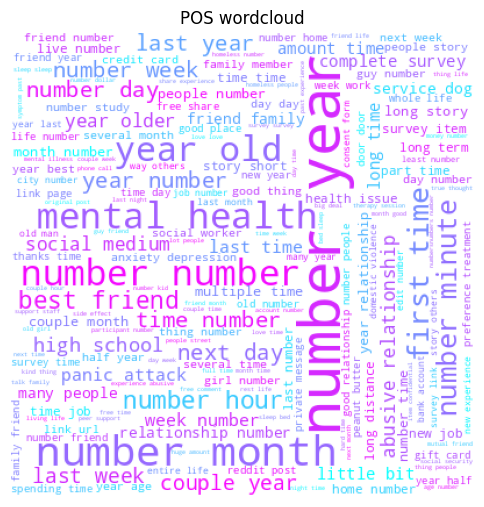

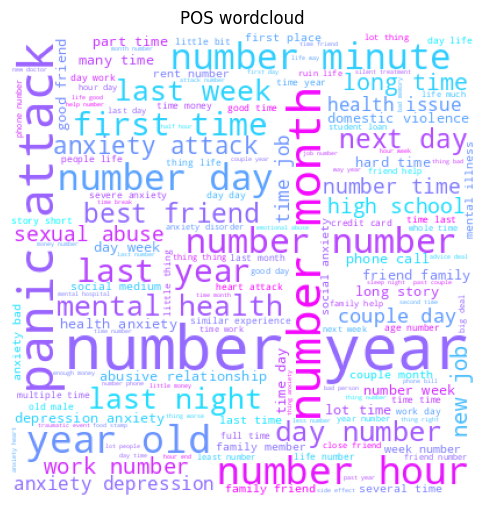

In [10]:
texts = train['new']
labels = train['labs']
uniquelabels = labels.unique()
for lab in uniquelabels:
  text = texts[labels == lab]
  combined = ' '.join(text)

  tokens = word_tokenize(combined)
  doc = nlp(combined)
  des_pos = ["NOUN", "ADJ"]
  filtered = [token.text for token in doc if token.pos_ in des_pos]

  bi_list = list(zip(filtered[:-1],filtered[1:]))
  phrases = (' '.join(x) for x in bi_list)
  bi_freq = Counter(phrases)

  wc = WordCloud(width = 400, height = 400, colormap = "cool", background_color= "white").generate_from_frequencies(bi_freq)

  plt.figure(figsize=(6,8))
  plt.imshow(wc)
  plt.axis("off")
  plt.title("POS wordcloud")
  plt.show()

FOR VALIDATION DATASET

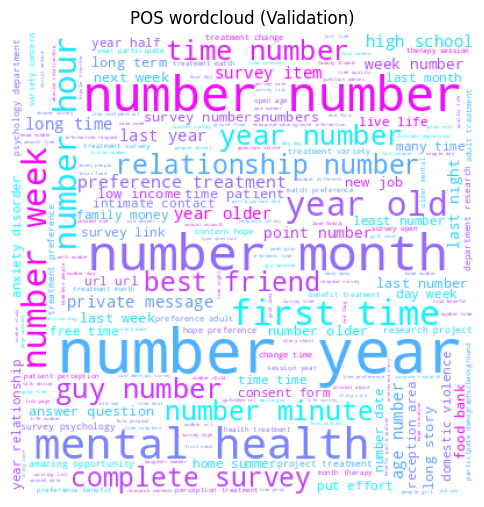

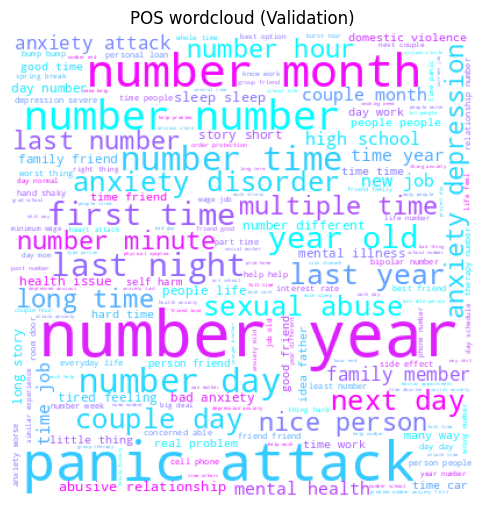

In [11]:
texts = val['new']
labels = val['labs']
uniquelabels = labels.unique()

for lab in uniquelabels:
    text = texts[labels == lab]
    combined = ' '.join(text)

    tokens = word_tokenize(combined)
    doc = nlp(combined)
    des_pos = ["NOUN", "ADJ"]
    filtered = [token.text for token in doc if token.pos_ in des_pos]

    bi_list = list(zip(filtered[:-1], filtered[1:]))
    phrases = (' '.join(x) for x in bi_list)
    bi_freq = Counter(phrases)

    wc = WordCloud(width = 400, height = 400, colormap = "cool", background_color= "white").generate_from_frequencies(bi_freq)

    plt.figure(figsize=(6,8))
    plt.imshow(wc)
    plt.axis("off")
    plt.title("POS wordcloud (Validation)")
    plt.show()


# Text **Classification**

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import recall_score, classification_report
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
X_train = vectorizer.fit_transform(train['new'])
y_train = train['labs']

X_val = vectorizer.transform(val['new'])
y_val = val['labs']

X_test = vectorizer.transform(test['new'])

#model 1
m1 = LinearSVC(max_iter=10000, C=0.4)
m1.fit(X_train, y_train)
y_train_pred1 = m1.predict(X_train)
y_val_pred1 = m1.predict(X_val)

train_recall = recall_score(y_train, y_train_pred1, average='macro')
val_recall = recall_score(y_val, y_val_pred1, average='macro')


print("Training Performance of model 1:")
print(classification_report(y_train, y_train_pred1))

# Validation performance of model 1
print("Validation Performance:")
print(classification_report(y_val, y_val_pred1))

Training Performance of model 1:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1620
           1       0.98      0.99      0.98      1785

    accuracy                           0.98      3405
   macro avg       0.98      0.98      0.98      3405
weighted avg       0.98      0.98      0.98      3405

Validation Performance:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85       540
           1       0.85      0.88      0.86       595

    accuracy                           0.86      1135
   macro avg       0.86      0.86      0.86      1135
weighted avg       0.86      0.86      0.86      1135



In [13]:
#model 2
m2 = LinearSVC(max_iter=10000, C=0.7)
m2.fit(X_train, y_train)
y_train_pred2 = m2.predict(X_train)
y_val_pred2 = m2.predict(X_val)

train_recall2 = recall_score(y_train, y_train_pred2, average = 'macro')
val_recall2 = recall_score(y_val, y_val_pred2, average = 'macro')

print("Training Performance of model 2:")
print(classification_report(y_train, y_train_pred2))

# Validation performance of model 2
print("Validation Performance:")
print(classification_report(y_val, y_val_pred2))


Training Performance of model 2:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1620
           1       0.99      0.99      0.99      1785

    accuracy                           0.99      3405
   macro avg       0.99      0.99      0.99      3405
weighted avg       0.99      0.99      0.99      3405

Validation Performance:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       540
           1       0.87      0.89      0.88       595

    accuracy                           0.87      1135
   macro avg       0.87      0.87      0.87      1135
weighted avg       0.87      0.87      0.87      1135



In [14]:
#model 3
m3 = LinearSVC(max_iter=10000, C=0.9)
m3.fit(X_train, y_train)
y_train_pred3 = m3.predict(X_train)
y_val_pred3 =m3.predict(X_val)

train_recall3 = recall_score(y_train, y_train_pred3, average ='macro')
val_recall3 = recall_score(y_val, y_val_pred3, average = 'macro')

print("Training Performance of model 3:")
print(classification_report(y_train, y_train_pred3))

# Validation performance of model 3
print("Validation Performance:")
print(classification_report(y_val, y_val_pred3))

Training Performance of model 3:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1620
           1       0.99      1.00      0.99      1785

    accuracy                           0.99      3405
   macro avg       0.99      0.99      0.99      3405
weighted avg       0.99      0.99      0.99      3405

Validation Performance:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       540
           1       0.88      0.89      0.88       595

    accuracy                           0.88      1135
   macro avg       0.88      0.88      0.88      1135
weighted avg       0.88      0.88      0.88      1135



test prediction from model 1

In [15]:
test_pred1 = m1.predict(X_test)
print(test_pred1[:20])

submission = pd.DataFrame({'label': test_pred1})
submission.to_csv('model1_pred.csv', index=False)
print("done")

[0 0 0 1 1 1 1 0 1 1 0 1 0 0 1 0 1 0 1 1]
done


test prediction from model 2

In [16]:
test_pred2 = m2.predict(X_test)
print(test_pred2[:20])

submission = pd.DataFrame({'label': test_pred2})
submission.to_csv('model2_pred.csv', index=False)
print("done")

[0 0 0 1 1 1 1 0 1 1 0 1 0 0 1 0 1 0 1 0]
done


test prediction from model 3

In [17]:
test_pred3 = m3.predict(X_test)
print(test_pred3[:20])

submit = pd.DataFrame({'label': test_pred3})
submit.to_csv('model3_pred.csv', index=False)
print("done")



[0 0 0 1 1 1 1 0 1 1 0 1 0 0 1 0 1 0 1 0]
done
